# Can total played hours on a MineCraft Server and gender predict whether a person will subscribe to a gaming-related newsletter?

**By: Sabine Elsaadany, Natalie Katanchik, Brianna Lin, Simon Littlewood**

## **Introduction**

The following report aims to explore whether the total number of hours played on a Minecraft server and the gender of the player can accurately predict the player's subscription status (i.e. subscribed or not subscribed). The data observed is from a research group in Computer Science at UBC, exploring how people play video games. Players' navigation of the world is recorded. The team created 2 CSV files - players.csv, observing unique players and data about them, and sessions.csv, observing individual play sessions and information about the session. 

**Purpose of Study:** To target recruitment efforts. This report concerns data from players.csv. Specifically, we wish to answer the question: Can played hours and gender predict subscription using the players.csv data set?

Players.csv (196 rows) 
- 7 (explored) columns: 
  - 2 decimal:
    - Age (of user) 
    - played_hours (indicating users' hours played). 
  - 3 character:
    - experience (specifies user gaming experience - pro, veteran, amateur, regular, beginner)
    - name
    - gender (male, female, prefer not to say, non-binary, other, two-spirited, agender).
    - hashedEmail (email of user - hashed) - one per player
  - 1 logical:  
    - Subscribe (indicates whether the user is subscribed to a game newsletter - TRUE/FALSE).
   
*Note: By explored, we mean that this players.csv dataset (attached via URL) has extra columns that the version on canvas did not have, such as individualID and organizationName. We are excluding these, as they are not in the canvas version or relevant to our project.*


**Justification:**
- Number of hours played has a relationship with subscription status (further observed below).
- Player gender seems to have a relationship with subscription status (further observed below). 

In [1]:
library(tidyverse)
library(dplyr)
library(tidymodels)
set.seed(4321) 

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
── Attaching packages ────────────────────────────────────── tidymodels 1.1.1 ──

✔ broom        1.0.6     ✔ rsample      1.2.1
✔ dials        1.3.0     ✔ tune         1.1.2
✔ infer        1.0.7     ✔ workflows    1.1.4
✔ modeldata    1.4.0     ✔ workflowsets 1.0.1
✔ parsnip      1.2.1     ✔ yardstick    1.3.1
✔ recipes      1.1.0     

── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ scales::discard() masks purrr::discard()
✖ dplyr::filt

In [2]:
url <- "https://drive.google.com/uc?export=download&id=1Mw9vW0hjTJwRWx0bDXiSpYsO3gKogaPz"
players <- read_csv(url)
head(players)

Rows: 196 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, age
lgl (3): subscribe, individualId, organizationName

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


experience,subscribe,hashedEmail,played_hours,name,gender,age,individualId,organizationName
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<lgl>,<lgl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9,NA,NA
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17,NA,NA
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17,NA,NA
Amateur,TRUE,23fe711e0e3b77f1da7aa221ab1192afe21648d47d2b4fa7a5a659ff443a0eb5,0.7,Flora,Female,21,NA,NA
Regular,TRUE,7dc01f10bf20671ecfccdac23812b1b415acd42c2147cb0af4d48fcce2420f3e,0.1,Kylie,Male,21,NA,NA
Amateur,TRUE,f58aad5996a435f16b0284a3b267f973f9af99e7a89bee0430055a44fa92f977,0.0,Adrian,Female,17,NA,NA


**Wrangled Data** - We removed NAs (as they skew data) and turned the subscribe variable into a factor as that will be the response variable in our classification question. We also renamed Age to age and hashedEmail to hashed_email for clarity (matching naming trend of the other columns in the dataset).

In [3]:
players <- players |>
    select(experience, subscribe, hashedEmail, played_hours, name, gender, age) |>
    drop_na() |>
    mutate(subscribe = as.factor(subscribe)) |>
    rename(hashed_email=hashedEmail)

head(players)

experience,subscribe,hashed_email,played_hours,name,gender,age
<chr>,<fct>,<chr>,<dbl>,<chr>,<chr>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
Amateur,TRUE,23fe711e0e3b77f1da7aa221ab1192afe21648d47d2b4fa7a5a659ff443a0eb5,0.7,Flora,Female,21
Regular,TRUE,7dc01f10bf20671ecfccdac23812b1b415acd42c2147cb0af4d48fcce2420f3e,0.1,Kylie,Male,21
Amateur,TRUE,f58aad5996a435f16b0284a3b267f973f9af99e7a89bee0430055a44fa92f977,0.0,Adrian,Female,17


## **Methods & Results**

Since we are predicting a categorical variable, our analysis will be done using the knn-classification model. We will be using played_hours and gender as predictors, and subscribe as our response variable. However, because gender is a qualitative variable, we must first transform it into a numerical format so that knn can perform distance calculations. A five-fold cross-validation will then be performed on the training set, after which we can identify the best K value to use in our model. Finally, we acknowledge that there are limitations to this method and that complications may arise if one of our classes is overrepresented, or if we have multiple predictor variables (in our case, gender has seven unique categories).

### Context

**Subscribe:** We may need to oversample rare class (FALSE) in prediction due to imbalances in our response variable.

In [4]:
subscribe_count <- players|>
count(subscribe)

subscribe_count

subscribe,n
<fct>,<int>
FALSE,52
TRUE,144


**Gender:** Mostly males, followed by females. Unequal distribution. Therefore, we are looking at this predictor by rate subscribed rather than just quantity. 

In [5]:
gender_count <- players |>
  count(gender)

gender_count

gender,n
<chr>,<int>
Agender,2
Female,37
Male,124
Non-binary,15
Other,1
Prefer not to say,11
Two-Spirited,6


**Played Hours:** 85/196 played 0 hours, and many more played less than 1 full hour - this raises concern. 

In [6]:
played_hours_count <- players|>
count(played_hours)

head(played_hours_count, 11)

played_hours,n
<dbl>,<int>
0.0,85
0.1,34
0.2,10
0.3,5
0.4,5
0.5,4
0.6,5
0.7,3
0.8,2


### Justification

Proportion data computed to understand the counts better, accounts for category imbalances - relevant for graphs.

In [7]:
ratio_gender_subscribed <- players |>
  group_by(gender) |>
  summarize(
    total = n(),
    subscribed = sum(subscribe == TRUE),
    percentage_subscribed = (subscribed / total)*100)

ratio_gender_subscribed

gender,total,subscribed,percentage_subscribed
<chr>,<int>,<int>,<dbl>
Agender,2,2,100.00000
Female,37,29,78.37838
Male,124,93,75.00000
Non-binary,15,11,73.33333
Other,1,1,100.00000
Prefer not to say,11,4,36.36364
Two-Spirited,6,4,66.66667


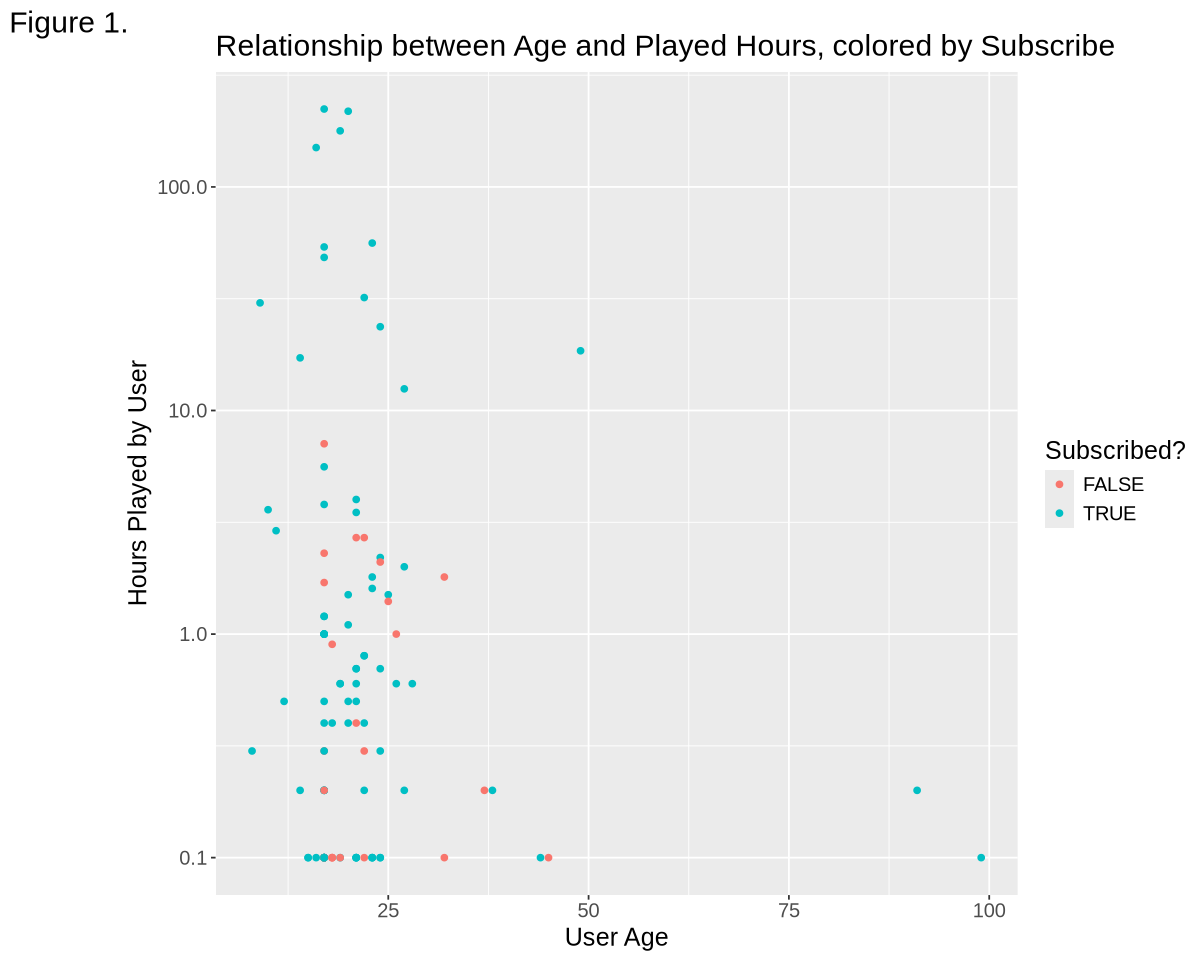

In [8]:
options(repr.plot.width = 10, repr.plot.height = 8)
age_vs_played_hours <- players|>
    filter(played_hours > 0) |>
    ggplot(aes(x = age, y = played_hours, color = subscribe)) +
    geom_point() +
    scale_y_log10() +
    labs(x = "User Age", y = "Hours Played by User", color = "Subscribed?", tag = "Figure 1.") +
    ggtitle("Relationship between Age and Played Hours, colored by Subscribe") +
    theme(text = element_text(size = 15))

age_vs_played_hours

Above is a scatter plot of age vs. played_hours, colored by subscribed.

Conclusions drawn from graph:
- Age does not have a relationship with subscription.
- More data points for younger players (<25).
- Higher played hours correlate with subscription (all data with played_hours > 10 = subscribed).
- played_hours likely predictive of subscription.
- Limitation of played_hours is the unequal distribution of data (85/196 are at 0 played hours), but since it is the only quantitative variable with a relationship to subscription in the players dataset, it will be used as a predictor. 

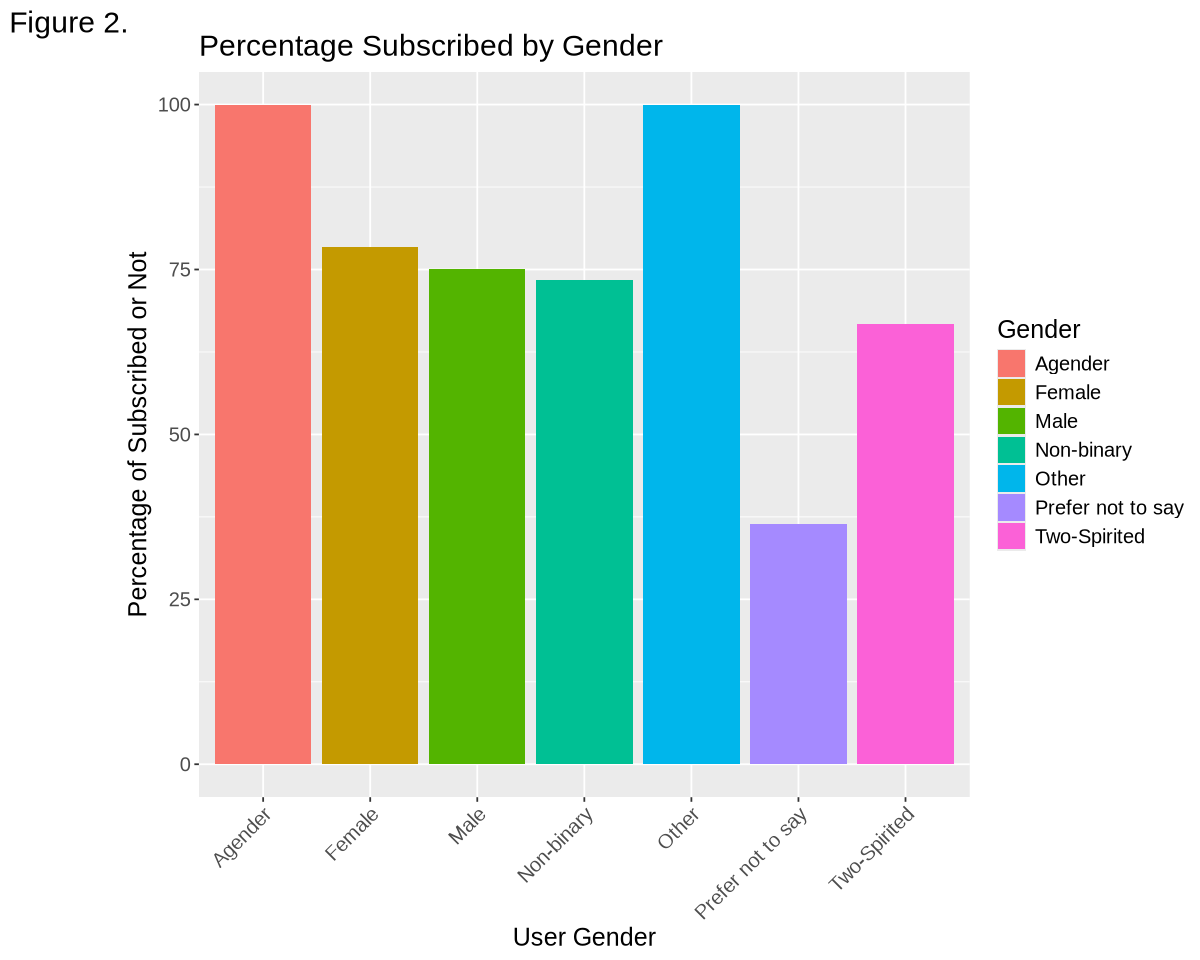

In [9]:
options(repr.plot.width = 10, repr.plot.height = 8)
gender_subscribed_ratio_bar <- ratio_gender_subscribed |>
    ggplot(aes(x = gender, y = percentage_subscribed, fill = gender)) +
    geom_bar(stat = "identity") +
    labs(x = "User Gender", y = "Percentage of Subscribed or Not", fill = "Gender", tag = "Figure 2.") +
    ggtitle("Percentage Subscribed by Gender") +
    theme(text = element_text(size = 15),
        axis.text.x = element_text(angle = 45, hjust = 1))

gender_subscribed_ratio_bar

Above is a bar plot of percentage of players subscribed colored by gender - we can conclude that women have the highest subscription rate (aside from Agender and Other that each only contain 1 player).
- Small-category sizes limit inference.
- Data limitations prevalent ( limited data for agender and other).
- Change in the dominating gender observed when looking at proportion instead of count.
- Likely a predictive variable.

As seen above, played_hours and gender are indicative of subscription status; looking at percent of players subscribed by gender proves that it is not just predictive of subscription due to limited data points. 

In [10]:
players_encoded <- players |>
        mutate(gender_male = ifelse(gender == "Male", 1, 0),
               gender_female = ifelse(gender == "Female", 1, 0),
               gender_nb = ifelse(gender == "Non-binary", 1, 0),
               gender_na = ifelse(gender == "Prefer not to say", 1, 0),
               gender_ts = ifelse(gender == "Two-Spirited", 1, 0),
               gender_agender = ifelse(gender == "Agender", 1, 0))

In [11]:
players_split<- initial_split(players_encoded, prop=0.7, strata=subscribe)
players_training <- training(players_split)
players_testing <- testing(players_split)

In [12]:
players_recipe <- recipe(subscribe~gender_male + gender_female + gender_nb + gender_na + gender_ts + gender_agender + played_hours, data=players_training) |>
step_scale(all_predictors()) |>
step_center(all_predictors())

In [13]:
knn_spec <- nearest_neighbor(weight_func = "rectangular", neighbors = tune()) |>
  set_engine("kknn") |>
  set_mode("classification")

In [14]:
k_vals <- tibble(neighbors = seq(from = 1, to = 100, by = 5))
players_vfold <- vfold_cv(players_training, v = 5, strata = subscribe)

We will use a K range of **1-100** to account for overfitting and underfitting. Although it's possible to select a larger range based on our dataset, this might cause performance issues.

In [15]:
players_fit <- workflow() |>
  add_recipe(players_recipe) |>
  add_model(knn_spec) |>
  tune_grid(resamples = players_vfold, grid = k_vals) |>
  collect_metrics()

accuracies <- players_fit |>
  filter(.metric == "accuracy")

→ A | warning: !  The following column has zero variance so scaling cannot be used:
                 gender_agender.
               ℹ Consider using ?step_zv (`?recipes::step_zv()`) to remove those columns
                 before normalizing.

There were issues with some computations   A: x1

There were issues with some computations   A: x1





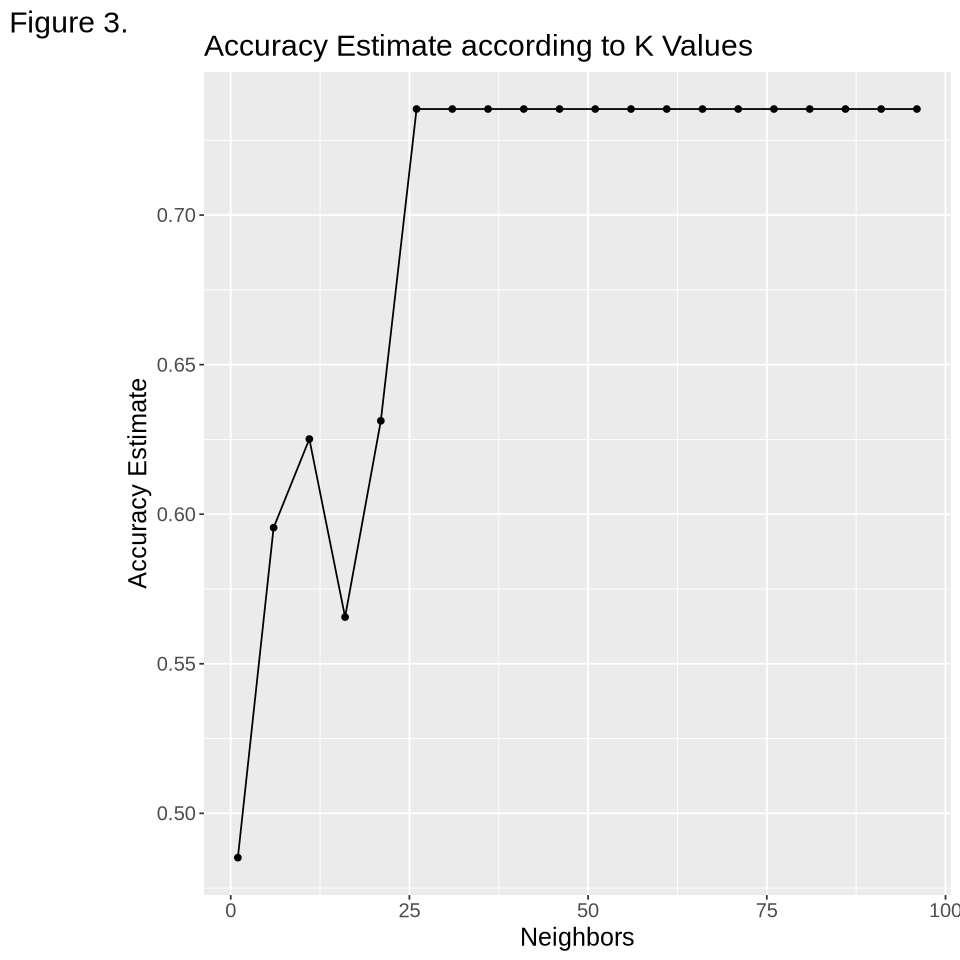

In [16]:
options(repr.plot.width = 8, repr.plot.height = 8)
accuracy_vs_k <- ggplot(accuracies, aes(x = neighbors, y = mean)) +
    geom_point() +
    geom_line() +
    labs(x = "Neighbors", y = "Accuracy Estimate", tag = "Figure 3.") +
    ggtitle("Accuracy Estimate according to K Values") +
    theme(text = element_text(size = 15))

accuracy_vs_k

In [17]:
best_k <- accuracies |>
        arrange(desc(mean)) |>
        head(1) |>
        pull(neighbors)
best_k

[1] 26

The above graph shows that the best K value lies between 26 and 100. Since the accuracy estimate plateaus after K = 25, we can assume that K values above 25 perform in the same way. Therefore, we will use a K of 26 to avoid complications during computation.

In [18]:
knn_spec <- nearest_neighbor(weight_func = "rectangular", neighbors = best_k) |>
    set_engine("kknn") |>
    set_mode("classification")

knn_fit <- workflow() |>
    add_recipe(players_recipe) |>
    add_model(knn_spec) |>
    fit(data = players_training)

In [19]:
players_test_predictions <- predict(knn_fit, players_testing) |>
    bind_cols(players_testing)

In [20]:
confusion_matrix <- players_test_predictions |>
    conf_mat(truth = subscribe, estimate = .pred_class)

confusion_matrix

          Truth
Prediction FALSE TRUE
     FALSE     2    0
     TRUE     14   44

The above confusion matrix shows that **14 observations** were incorrectly predicted as TRUE subscriptions. This could be due to a class imbalance in TRUE and FALSE subscription status (as mentioned earlier).

In [21]:
accuracy <- players_test_predictions |>
    metrics(truth = subscribe, estimate = .pred_class) |>
    filter(.metric == "accuracy")

precision <- players_test_predictions |>
    precision(truth = subscribe, estimate = .pred_class, event_level = "first")

recall <- players_test_predictions |>
    recall(truth = subscribe, estimate = .pred_class, event_level = "first")

accuracy
precision
recall

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
accuracy,binary,0.7666667


.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
precision,binary,1


.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
recall,binary,0.125


## **Discussion**

We found that gender and played_hours are somewhat predictive of subscription, with 76.6% accuracy. Moreover, as seen with the 14 incorrect TRUE predictions and 12.5% recall, we can further confirm the types of errors this model makes. It tends to produce false positives, which, in the context of this problem, does not pose a significant issue; however, it further reiterates the imperfections of this model. It is important to note, however, that the majority classifier produces approximately 73.5 percent accuracy if it predicts TRUE (subscribed) every time, thus the improvement to 76.6% is not by a significant margin. We originally predicted to find a much greater accuracy due to what we had originally seen with our exploratory data, suggesting that gender and played_hours would be predictors. 

Our next question is whether gender is more predictive than played hours or vice versa? Future research could observe whether one of the two predictors alone could improve the accuracy, rather than when put together. This could help the UBC Computer Science team conducting this research understand that gender and played_hours are somewhat helpful in predicting subscription, and thus aid them with their goal of being able to target recruitment efforts, potentially now focusing on those two variables. We were unable to determine which specific gender was the most predictive, and imbalances in the distribution of each gender may complicate this further. Future analysis must be done before any attempts to target a specific gender and amount of played hours are made. Once research is conducted regarding whether the individual predictors improve the quality of the model on their own, that can further aid with recruitment efforts, allowing the team to potentially focus on one predictor, rather than the two combined.